<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("email.csv")

In [4]:
X = df['text']
y = df['label']

In [6]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_vec = vectorizer.fit_transform(X).toarray()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
model = Sequential([
    Dense(1, input_dim=X_train.shape[1], activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9287 - loss: 0.5159 - val_accuracy: 0.9673 - val_loss: 0.2506
Epoch 2/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9679 - loss: 0.2180 - val_accuracy: 0.9721 - val_loss: 0.1560
Epoch 3/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9722 - loss: 0.1424 - val_accuracy: 0.9747 - val_loss: 0.1169
Epoch 4/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9758 - loss: 0.1098 - val_accuracy: 0.9772 - val_loss: 0.0963
Epoch 5/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9789 - loss: 0.0905 - val_accuracy: 0.9789 - val_loss: 0.0837


In [11]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

522/522 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.9789095266626723
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      7908
           1       0.98      0.98      0.98      8782

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



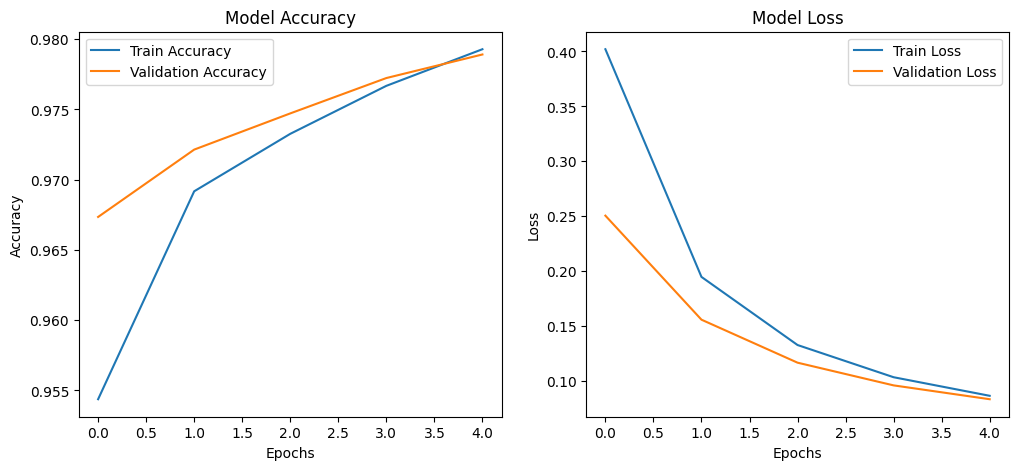

In [15]:
def plot_history(history):
    plt.figure(figsize=(12,5))


    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)


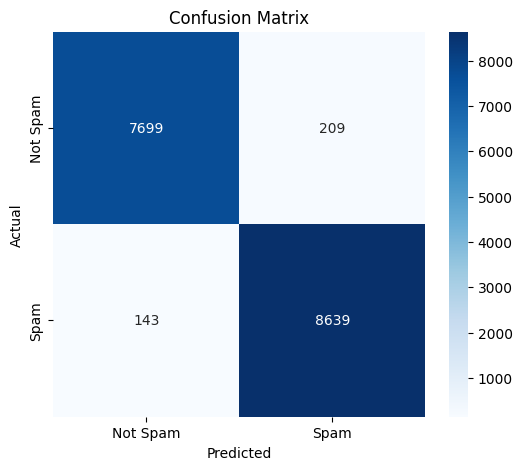

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
